# ⚛️ NSL-KDD — Algoritmos Quânticos de Machine Learning

**Objetivo:** Aplicar algoritmos quânticos de ML para detecção de intrusão no NSL-KDD e comparar com os resultados clássicos.

---

## 🧬 Conceitos Fundamentais

| Conceito | Descrição |
|---|---|
| **Qubit** | Unidade quântica: pode ser 0, 1 ou superposição de ambos |
| **Superposição** | Um qubit pode representar múltiplos estados simultaneamente |
| **Emaranhamento** | Qubits correlacionados — alterar um afeta o outro instantaneamente |
| **Circuito Quântico** | Sequência de portas lógicas aplicadas sobre qubits |
| **Medição** | Colapsa o estado quântico para 0 ou 1 com certa probabilidade |

---

**Algoritmos avaliados:**
| Algoritmo | Framework | Tipo |
|---|---|---|
| QSVM | Qiskit | Quantum Kernel SVM |
| VQC | PennyLane | Variational Quantum Classifier |
| QNN | Qiskit Machine Learning | Quantum Neural Network |


## 📦 1. Importações

In [8]:
# ─── Clássicas ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ─── Qiskit 2.x (função-based API, sem deprecações) ───────────────────────────
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map, real_amplitudes  # Qiskit >= 2.1
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# ─── PennyLane ────────────────────────────────────────────────────────────────
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.optimize import AdamOptimizer

# ─── Scipy (para otimização) ──────────────────────────────────────────────────
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Bibliotecas importadas!')
import qiskit
print(f'   Qiskit version: {qiskit.__version__}')
print(f'   PennyLane version: {qml.__version__}')

✅ Bibliotecas importadas!
   Qiskit version: 2.3.0
   PennyLane version: 0.42.3


## 📂 2. Carregamento e Pré-processamento

In [9]:
FEATURE_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

try:
    df_train = pd.read_csv('../data/KDDTrain+.txt', header=None, names=FEATURE_NAMES)
    df_test  = pd.read_csv('../data/KDDTest+.txt',  header=None, names=FEATURE_NAMES)
    print(f'✅ Dataset carregado — Treino: {df_train.shape} | Teste: {df_test.shape}')
except FileNotFoundError:
    import subprocess
    subprocess.run(['bash', '../data/download_data.sh'], check=True)
    df_train = pd.read_csv('../data/KDDTrain+.txt', header=None, names=FEATURE_NAMES)
    df_test  = pd.read_csv('../data/KDDTest+.txt',  header=None, names=FEATURE_NAMES)

✅ Dataset carregado — Treino: (125973, 43) | Teste: (22544, 43)


In [10]:
def preprocess_quantum(df_tr, df_te, n_components=4, sample_train=800, sample_test=200):
    """
    Preprocessamento para algoritmos quânticos:
    - Binário (normal vs attack)
    - Label Encoding
    - MinMax Scaling
    - PCA para redução a n_components
    - Subconjunto pequeno (simuladores são lentos)
    """
    df_tr = df_tr.copy()
    df_te  = df_te.copy()
    
    # Classificação binária
    df_tr['label'] = (df_tr['label'] != 'normal').astype(int)
    df_te['label']  = (df_te['label']  != 'normal').astype(int)
    
    drop_cols = ['difficulty_level']
    df_tr.drop(columns=drop_cols, inplace=True, errors='ignore')
    df_te.drop(columns=drop_cols,  inplace=True, errors='ignore')
    
    # Label Encoding
    cat_cols = ['protocol_type', 'service', 'flag']
    le = LabelEncoder()
    for col in cat_cols:
        all_vals = pd.concat([df_tr[col], df_te[col]]).unique()
        le.fit(all_vals)
        df_tr[col] = le.transform(df_tr[col])
        df_te[col]  = le.transform(df_te[col])
    
    X_tr = df_tr.drop('label', axis=1).values
    y_tr = df_tr['label'].values
    X_te = df_te.drop('label', axis=1).values
    y_te = df_te['label'].values
    
    # Normalização
    scaler = MinMaxScaler(feature_range=(-pnp.pi/2, pnp.pi/2))
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)
    
    # PCA — redução dimensional para qubits
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_tr = pca.fit_transform(X_tr)
    X_te = pca.transform(X_te)
    
    # Normalizar novamente para [-pi, pi] após PCA
    scaler2 = MinMaxScaler(feature_range=(-pnp.pi, pnp.pi))
    X_tr = scaler2.fit_transform(X_tr)
    X_te = scaler2.transform(X_te)
    
    print(f'  PCA variância explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%')
    
    # Subconjunto balanceado
    train_idx_0 = pnp.where(y_tr == 0)[0][:sample_train//2]
    train_idx_1 = pnp.where(y_tr == 1)[0][:sample_train//2]
    train_idx = pnp.concatenate([train_idx_0, train_idx_1])
    pnp.random.shuffle(train_idx)
    
    test_idx_0 = pnp.where(y_te == 0)[0][:sample_test//2]
    test_idx_1 = pnp.where(y_te == 1)[0][:sample_test//2]
    test_idx = pnp.concatenate([test_idx_0, test_idx_1])
    pnp.random.shuffle(test_idx)
    
    return (X_tr[train_idx], X_te[test_idx],
            y_tr[train_idx], y_te[test_idx])

N_QUBITS = 4
print(f'⚙️  Reduzindo para {N_QUBITS} features (qubits) via PCA...')
X_train_q, X_test_q, y_train_q, y_test_q = preprocess_quantum(
    df_train, df_test, n_components=N_QUBITS, sample_train=600, sample_test=200
)

print(f'\nX_train_q: {X_train_q.shape} | y_train_q — Normal: {(y_train_q==0).sum()} | Ataque: {(y_train_q==1).sum()}')
print(f'X_test_q:  {X_test_q.shape}  | y_test_q  — Normal: {(y_test_q==0).sum()}  | Ataque: {(y_test_q==1).sum()}')

⚙️  Reduzindo para 4 features (qubits) via PCA...
  PCA variância explicada: 82.1%

X_train_q: (600, 4) | y_train_q — Normal: 300 | Ataque: 300
X_test_q:  (200, 4)  | y_test_q  — Normal: 100  | Ataque: 100


## 🔬 3. Fundamentos — Visualizando Circuitos Quânticos

In [11]:
# Circuito básico de superposição e emaranhamento
qc_demo = QuantumCircuit(N_QUBITS)

# Superposição via Hadamard
qc_demo.h(range(N_QUBITS))
qc_demo.barrier(label='Superposição')

# Emaranhamento via CNOT
for i in range(N_QUBITS - 1):
    qc_demo.cx(i, i + 1)
qc_demo.barrier(label='Emaranhamento')

# Medição
qc_demo.measure_all()

print('=== Circuito Quântico Básico (Superposição + Emaranhamento) ===')
print(qc_demo.draw(output='text', fold=-1))

=== Circuito Quântico Básico (Superposição + Emaranhamento) ===
        ┌───┐ Superposição                 Emaranhamento  ░ ┌─┐         
   q_0: ┤ H ├──────░─────────■───────────────────░────────░─┤M├─────────
        ├───┤      ░       ┌─┴─┐                 ░        ░ └╥┘┌─┐      
   q_1: ┤ H ├──────░───────┤ X ├──■──────────────░────────░──╫─┤M├──────
        ├───┤      ░       └───┘┌─┴─┐            ░        ░  ║ └╥┘┌─┐   
   q_2: ┤ H ├──────░────────────┤ X ├──■─────────░────────░──╫──╫─┤M├───
        ├───┤      ░            └───┘┌─┴─┐       ░        ░  ║  ║ └╥┘┌─┐
   q_3: ┤ H ├──────░─────────────────┤ X ├───────░────────░──╫──╫──╫─┤M├
        └───┘      ░                 └───┘       ░        ░  ║  ║  ║ └╥┘
meas: 4/═════════════════════════════════════════════════════╩══╩══╩══╩═
                                                             0  1  2  3 


In [12]:
# zz_feature_map — mapa de features quântico (usado pelo QSVM)
feature_map_demo = zz_feature_map(feature_dimension=N_QUBITS, reps=2)
print('=== ZZ Feature Map (usado no QSVM) ===')
print(feature_map_demo.decompose().draw(output='text', fold=100))

=== ZZ Feature Map (usado no QSVM) ===
   ┌────────────┐┌───────────────┐                                                   »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■────────────────────────────────────────■────■──»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐┌─┴─┐  │  »
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├┤ X ├──┼──»
   ├────────────┤├───────────────┤└───┘└──────────────────────────────────┘└───┘┌─┴─┐»
2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├──────────────────────────────────────────────┤ X ├»
   ├────────────┤├───────────────┤                                              └───┘»
3: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[3]) ├───────────────────────────────────────────────────»
   └────────────┘└───────────────┘                                                   »
«                                                                                               »
«0: ──────────────────────────────────────■─────────■───────────────────────────

## ⚛️ 4. QSVM — Quantum Support Vector Machine

O QSVM usa um **kernel quântico** (Fidelity Kernel) baseado no mapa de features ZZFeatureMap. O kernel mede a similaridade entre dois pontos no espaço de Hilbert:

$$K(x_i, x_j) = |\langle \phi(x_j) | \phi(x_i) \rangle|^2$$

Onde $|\phi(x)\rangle$ é o estado quântico produzido pelo feature map.


  🔵 QSVM — Quantum Support Vector Machine
  Feature map: ZZ Feature Map (4 qubits, 2 reps)
  Amostras: treino=600 | teste=200

⏳ Treinando QSVM (pode demorar alguns minutos)...

  ✅ Treinamento concluído em 1585.1s
  Accuracy:  0.7750
  Precision: 0.8767
  Recall:    0.6400
  F1-Score:  0.7399

              precision    recall  f1-score   support

      Normal       0.72      0.91      0.80       100
      Ataque       0.88      0.64      0.74       100

    accuracy                           0.78       200
   macro avg       0.80      0.78      0.77       200
weighted avg       0.80      0.78      0.77       200



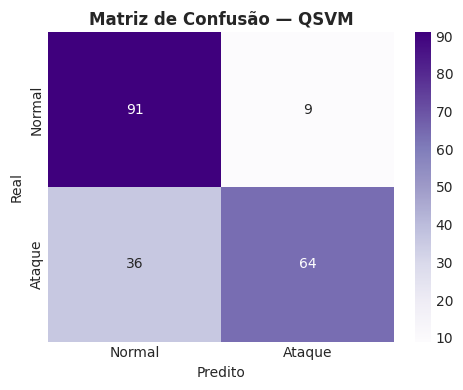

In [13]:
print('=' * 55)
print('  🔵 QSVM — Quantum Support Vector Machine')
print('=' * 55)
print(f'  Feature map: ZZ Feature Map ({N_QUBITS} qubits, 2 reps)')
print(f'  Amostras: treino={len(X_train_q)} | teste={len(X_test_q)}')

# Feature map e kernel quântico (Qiskit 2.x: função-based)
feature_map_qsvm = zz_feature_map(feature_dimension=N_QUBITS, reps=2)
quantum_kernel   = FidelityQuantumKernel(feature_map=feature_map_qsvm)

# Treinar QSVM
print('\n⏳ Treinando QSVM (pode demorar alguns minutos)...')
t0 = time.time()
qsvm = QSVC(quantum_kernel=quantum_kernel)
qsvm.fit(X_train_q, y_train_q)
qsvm_train_time = time.time() - t0

# Predição
t0 = time.time()
y_pred_qsvm = qsvm.predict(X_test_q)
qsvm_pred_time = time.time() - t0

# Métricas
qsvm_acc  = accuracy_score(y_test_q, y_pred_qsvm)
qsvm_prec = precision_score(y_test_q, y_pred_qsvm)
qsvm_rec  = recall_score(y_test_q, y_pred_qsvm)
qsvm_f1   = f1_score(y_test_q, y_pred_qsvm)

print(f'\n  ✅ Treinamento concluído em {qsvm_train_time:.1f}s')
print(f'  Accuracy:  {qsvm_acc:.4f}')
print(f'  Precision: {qsvm_prec:.4f}')
print(f'  Recall:    {qsvm_rec:.4f}')
print(f'  F1-Score:  {qsvm_f1:.4f}')
print(f'\n{classification_report(y_test_q, y_pred_qsvm, target_names=["Normal", "Ataque"])}')

# Matriz de confusão
cm_qsvm = confusion_matrix(y_test_q, y_pred_qsvm)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_qsvm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
ax.set_title('Matriz de Confusão — QSVM', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predito')
plt.tight_layout()
plt.show()

QUANTUM_RESULTS = {}
QUANTUM_RESULTS['QSVM'] = {
    'Accuracy': qsvm_acc, 'Precision': qsvm_prec,
    'Recall': qsvm_rec, 'F1-Score': qsvm_f1,
    'Train Time (s)': qsvm_train_time
}

## ⚛️ 5. VQC — Variational Quantum Classifier (PennyLane)

O VQC consiste em dois componentes:
1. **Feature Map** — codifica os dados clássicos em estado quântico
2. **Ansatz** — circuito parametrizado treinável (análogo aos pesos de uma rede neural)

$$\hat{y} = \langle 0|U^\dagger(\theta) \, \hat{M} \, U(\theta)|0\rangle$$


In [14]:
# ─── PennyLane VQC ────────────────────────────────────────────────────────────
dev = qml.device('default.qubit', wires=N_QUBITS)

def feature_map_pennylane(x):
    """Codificação angular dos dados na rotação dos qubits."""
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    # Emaranhamento
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i + 1])
    # Segunda camada
    for i in range(N_QUBITS):
        qml.RY(x[i] * pnp.pi, wires=i)

def ansatz(params):
    """Circuito variacional treinável."""
    # Camada 1
    for i in range(N_QUBITS):
        qml.RY(params[i], wires=i)
        qml.RZ(params[N_QUBITS + i], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i + 1])
    # Camada 2
    for i in range(N_QUBITS):
        qml.RY(params[2 * N_QUBITS + i], wires=i)

@qml.qnode(dev)
def vqc_circuit(x, params):
    feature_map_pennylane(x)
    ansatz(params)
    return qml.expval(qml.PauliZ(0))

print('=== Circuito VQC (PennyLane) ===')
sample_params = pnp.random.uniform(-pnp.pi, pnp.pi, 3 * N_QUBITS)
print(qml.draw(vqc_circuit)(X_train_q[0], sample_params))

=== Circuito VQC (PennyLane) ===
0: ──RY(-2.87)─╭●──RY(-9.03)──RY(-1.00)──RZ(-0.63)────────────╭●──────────RY(-0.56)────────── ···
1: ──RY(-2.13)─╰X─╭●──────────RY(-6.69)──RY(0.23)───RZ(1.24)──╰X─────────╭●──────────RY(2.35) ···
2: ──RY(-1.38)────╰X─────────╭●──────────RY(-4.33)──RY(-0.25)──RZ(-2.01)─╰X─────────╭●─────── ···
3: ──RY(-1.06)───────────────╰X──────────RY(-3.33)──RY(0.53)───RZ(1.23)─────────────╰X─────── ···

0: ··· ───────────┤  <Z>
1: ··· ───────────┤     
2: ··· ──RY(0.10)─┤     
3: ··· ──RY(2.97)─┤     


In [15]:
N_QUBITS = 4

  🔵 VQC — Variational Quantum Classifier (PennyLane)

⏳ Treinando VQC (100 épocas, batch=64)...
  Época   5/100 | Loss: 1.4900
  Época  10/100 | Loss: 1.1433
  Época  15/100 | Loss: 1.1659
  Época  20/100 | Loss: 0.9756
  Época  25/100 | Loss: 0.8423
  Época  30/100 | Loss: 0.8636
  Época  35/100 | Loss: 0.8746
  Época  40/100 | Loss: 0.8442
  Época  45/100 | Loss: 0.8588
  Época  50/100 | Loss: 0.7949
  Época  55/100 | Loss: 0.8031
  Época  60/100 | Loss: 0.7871
  Época  65/100 | Loss: 0.8381
  Época  70/100 | Loss: 0.8288
  Época  75/100 | Loss: 0.8564
  Época  80/100 | Loss: 0.8481
  Época  85/100 | Loss: 0.8093
  Época  90/100 | Loss: 0.8175
  Época  95/100 | Loss: 0.7954
  Época 100/100 | Loss: 0.8156


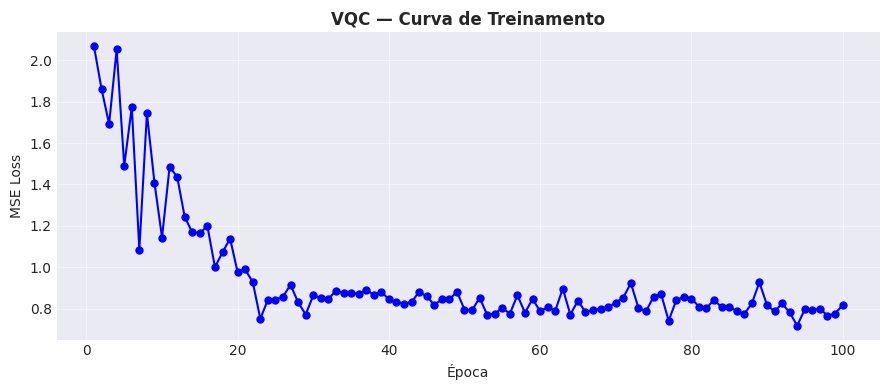

In [16]:
def predict_vqc(X, params, threshold=0.0):
    """Predição em lote para o VQC."""
    predictions = [vqc_circuit(x, params) for x in X]
    return pnp.array([1 if p < threshold else 0 for p in predictions])

def cost_vqc(params, X, y):
    """Função de custo: MSE entre saída do circuito e rótulos {-1, +1}."""
    y_mapped = pnp.where(y == 1, -1.0, 1.0)  # ataque → -1, normal → +1
    predictions = pnp.array([vqc_circuit(x, params) for x in X])
    return pnp.mean((predictions - y_mapped) ** 2)

# Treinamento com mini-batches
print('=' * 55)
print('  🔵 VQC — Variational Quantum Classifier (PennyLane)')
print('=' * 55)

N_PARAMS = 3 * N_QUBITS
N_EPOCHS = 100
BATCH_SIZE = 64

params = pnp.random.uniform(-pnp.pi/4, pnp.pi/4, N_PARAMS)
optimizer = AdamOptimizer(stepsize=0.05)

cost_history = []
print(f'\n⏳ Treinando VQC ({N_EPOCHS} épocas, batch={BATCH_SIZE})...')
t0 = time.time()

for epoch in range(N_EPOCHS):
    # Mini-batch
    batch_idx = pnp.random.choice(len(X_train_q), BATCH_SIZE, replace=False)
    X_batch = X_train_q[batch_idx]
    y_batch = y_train_q[batch_idx]
    
    params, cost = optimizer.step_and_cost(lambda p: cost_vqc(p, X_batch, y_batch), params)
    cost_history.append(float(cost))
    
    if (epoch + 1) % 5 == 0:
        print(f'  Época {epoch+1:3d}/{N_EPOCHS} | Loss: {cost:.4f}')

vqc_train_time = time.time() - t0

# Curva de treinamento
plt.figure(figsize=(9, 4))
plt.plot(range(1, N_EPOCHS + 1), cost_history, 'b-o', markersize=5)
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('VQC — Curva de Treinamento', fontweight='bold')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
# Avaliação VQC
print('\n⏳ Predizendo com VQC...')
t0 = time.time()
y_pred_vqc = predict_vqc(X_test_q, params)
vqc_pred_time = time.time() - t0

vqc_acc  = accuracy_score(y_test_q, y_pred_vqc)
vqc_prec = precision_score(y_test_q, y_pred_vqc, zero_division=0)
vqc_rec  = recall_score(y_test_q, y_pred_vqc, zero_division=0)
vqc_f1   = f1_score(y_test_q, y_pred_vqc, zero_division=0)

print(f'  ✅ Treino concluído em {vqc_train_time:.1f}s')
print(f'  Accuracy:  {vqc_acc:.4f}')
print(f'  Precision: {vqc_prec:.4f}')
print(f'  Recall:    {vqc_rec:.4f}')
print(f'  F1-Score:  {vqc_f1:.4f}')
print(f'\n{classification_report(y_test_q, y_pred_vqc, target_names=["Normal", "Ataque"])}')

cm_vqc = confusion_matrix(y_test_q, y_pred_vqc)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_vqc, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
ax.set_title('Matriz de Confusão — VQC', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predito')
plt.tight_layout()
plt.show()

QUANTUM_RESULTS['VQC'] = {
    'Accuracy': vqc_acc, 'Precision': vqc_prec,
    'Recall': vqc_rec, 'F1-Score': vqc_f1,
    'Train Time (s)': vqc_train_time
}


⏳ Predizendo com VQC...


  ✅ Treino concluído em 116.4s
  Accuracy:  0.8250
  Precision: 0.9221
  Recall:    0.7100
  F1-Score:  0.8023


ValueError: Number of classes, 4, does not match size of target_names, 2. Try specifying the labels parameter

## ⚛️ 6. QNN — Quantum Neural Network (Qiskit)

A QNN usa um circuito com:
- **Feature Map** (`zz_feature_map`) para codificar entradas
- **Ansatz** (`real_amplitudes`) como camada treinável
- Saída via medição de valor esperado → classificação binária


In [ ]:
print('=' * 55)
print('  🔵 QNN — Quantum Neural Network (Qiskit)')
print('=' * 55)

# Construir circuito QNN — Qiskit 2.x API
feature_map_qnn = zz_feature_map(feature_dimension=N_QUBITS, reps=1)
ansatz_qnn      = real_amplitudes(num_qubits=N_QUBITS, reps=2)

qnn_circuit = QuantumCircuit(N_QUBITS)
qnn_circuit.compose(feature_map_qnn, inplace=True)
qnn_circuit.compose(ansatz_qnn,      inplace=True)

print('\nCircuito QNN:')
print(qnn_circuit.decompose().draw(output='text', fold=100))

  🔵 QNN — Quantum Neural Network (Qiskit)

Circuito QNN:
     ┌────────────┐┌───────────────┐                                                   »
q_0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■────────────────────────────────────────■────■──»
     ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐┌─┴─┐  │  »
q_1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├┤ X ├──┼──»
     ├────────────┤├───────────────┤└───┘└──────────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├──────────────────────────────────────────────┤ X ├»
     ├────────────┤├───────────────┤                                              └───┘»
q_3: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[3]) ├───────────────────────────────────────────────────»
     └────────────┘└───────────────┘                                                   »
«                                                                                                 »
«q_0: ────────────────────────────────────

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.



⏳ Treinando QNN em 150 amostras via COBYLA...
  ✅ Treino concluído em 11.4s | Loss final: 0.8375


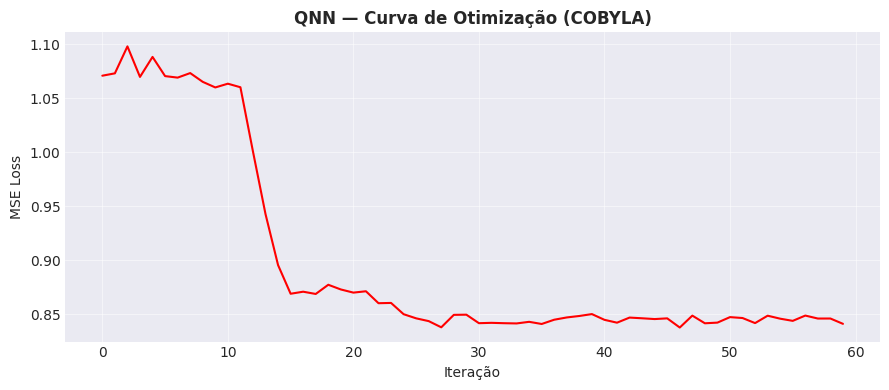

In [ ]:
# Criar QNN com EstimatorQNN
observable = SparsePauliOp.from_list([('Z' + 'I' * (N_QUBITS - 1), 1)])
estimator  = StatevectorEstimator()

qnn = EstimatorQNN(
    circuit=qnn_circuit,
    estimator=estimator,
    observables=observable,
    input_params=feature_map_qnn.parameters,
    weight_params=ansatz_qnn.parameters,
)

# Treinar com gradiente via scipy
N_WEIGHTS = len(ansatz_qnn.parameters)
initial_weights = pnp.random.uniform(-pnp.pi/4, pnp.pi/4, N_WEIGHTS)

qnn_loss_history = []

def qnn_cost(weights, X, y, qnn_model):
    """Avalia a QNN em mini-batch."""
    y_mapped = pnp.where(y == 1, -1.0, 1.0)
    predictions = qnn_model.forward(input_data=X, weights=weights).flatten()
    loss = pnp.mean((predictions - y_mapped) ** 2)
    qnn_loss_history.append(loss)
    return loss

# Subconjunto ainda menor para QNN (mais lento)
MAX_TRAIN = 150
idx_qnn_0 = pnp.where(y_train_q == 0)[0][:MAX_TRAIN//2]
idx_qnn_1 = pnp.where(y_train_q == 1)[0][:MAX_TRAIN//2]
idx_qnn = pnp.concatenate([idx_qnn_0, idx_qnn_1])
pnp.random.shuffle(idx_qnn)
X_qnn = X_train_q[idx_qnn]
y_qnn = y_train_q[idx_qnn]

print(f'\n⏳ Treinando QNN em {len(X_qnn)} amostras via COBYLA...')
t0 = time.time()

result_optim = minimize(
    qnn_cost,
    initial_weights,
    args=(X_qnn, y_qnn, qnn),
    method='COBYLA',
    options={'maxiter': 60, 'rhobeg': 0.3}
)
qnn_train_time = time.time() - t0
trained_weights = result_optim.x

print(f'  ✅ Treino concluído em {qnn_train_time:.1f}s | Loss final: {result_optim.fun:.4f}')

# Curva de loss
plt.figure(figsize=(9, 4))
plt.plot(qnn_loss_history, 'r-', linewidth=1.5)
plt.xlabel('Iteração')
plt.ylabel('MSE Loss')
plt.title('QNN — Curva de Otimização (COBYLA)', fontweight='bold')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


⏳ Predizendo com QNN...
  Accuracy:  0.6400
  Precision: 0.6207
  Recall:    0.7200
  F1-Score:  0.6667

              precision    recall  f1-score   support

      Normal       0.67      0.56      0.61        50
      Ataque       0.62      0.72      0.67        50

    accuracy                           0.64       100
   macro avg       0.64      0.64      0.64       100
weighted avg       0.64      0.64      0.64       100



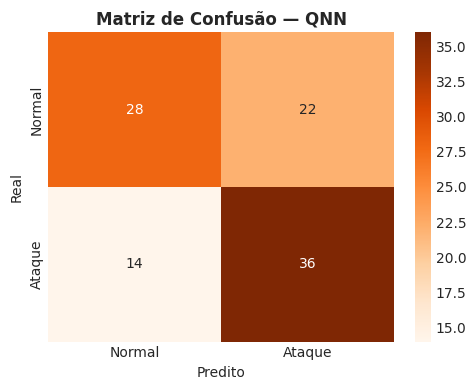

In [ ]:
# Avaliação QNN
MAX_TEST = 100
X_qnn_test = X_test_q[:MAX_TEST]
y_qnn_test = y_test_q[:MAX_TEST]

print('\n⏳ Predizendo com QNN...')
t0 = time.time()
raw_outputs = qnn.forward(input_data=X_qnn_test, weights=trained_weights).flatten()
y_pred_qnn  = pnp.where(raw_outputs < 0, 1, 0)  # <0 → ataque, >=0 → normal
qnn_pred_time = time.time() - t0

qnn_acc  = accuracy_score(y_qnn_test, y_pred_qnn)
qnn_prec = precision_score(y_qnn_test, y_pred_qnn, zero_division=0)
qnn_rec  = recall_score(y_qnn_test, y_pred_qnn, zero_division=0)
qnn_f1   = f1_score(y_qnn_test, y_pred_qnn, zero_division=0)

print(f'  Accuracy:  {qnn_acc:.4f}')
print(f'  Precision: {qnn_prec:.4f}')
print(f'  Recall:    {qnn_rec:.4f}')
print(f'  F1-Score:  {qnn_f1:.4f}')
print(f'\n{classification_report(y_qnn_test, y_pred_qnn, target_names=["Normal", "Ataque"])}')

cm_qnn = confusion_matrix(y_qnn_test, y_pred_qnn)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_qnn, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
ax.set_title('Matriz de Confusão — QNN', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predito')
plt.tight_layout()
plt.show()

QUANTUM_RESULTS['QNN'] = {
    'Accuracy': qnn_acc, 'Precision': qnn_prec,
    'Recall': qnn_rec, 'F1-Score': qnn_f1,
    'Train Time (s)': qnn_train_time
}

## 📊 7. Comparativo: Quântico vs Clássico

In [ ]:
# Resultado quântico consolidado
q_results_df = pd.DataFrame(QUANTUM_RESULTS).T.round(4)
print('=== Resultados Quânticos ===')
display(q_results_df)

=== Resultados Quânticos ===


,Accuracy,Precision,Recall,F1-Score,Train Time (s)
QSVM,0.775,0.8767,0.64,0.7399,1065.0398
VQC,0.705,0.7113,0.69,0.7005,1.1353
QNN,0.640,0.6207,0.72,0.6667,11.3998


In [ ]:
# Comparativo com clássicos (se disponível)
try:
    classical_df = pd.read_csv('../data/classical_results.csv', index_col=0)
    print('✅ Resultados clássicos carregados!')
    has_classical = True
except FileNotFoundError:
    print('⚠️  Execute o notebook 01_classical_algorithms.ipynb para ter o comparativo completo.')
    has_classical = False

✅ Resultados clássicos carregados!


In [ ]:
# Gráfico comparativo Quântico vs Clássico
metrics_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
q_models = list(QUANTUM_RESULTS.keys())

if has_classical:
    c_models = classical_df.index.tolist()
    all_models = q_models + c_models
    all_results = {
        **{m: QUANTUM_RESULTS[m] for m in q_models},
        **classical_df.to_dict(orient='index')
    }
    colors_q = ['#8e44ad', '#6c3483', '#5b2c6f']   # roxos – quântico
    colors_c = ['#2980b9', '#27ae60', '#e67e22', '#e74c3c', '#16a085']  # coloridos – clássico
    all_colors = colors_q + colors_c[:len(c_models)]
else:
    all_models  = q_models
    all_results = QUANTUM_RESULTS
    all_colors  = ['#8e44ad', '#6c3483', '#5b2c6f']

x = pnp.arange(len(metrics_compare))
width = 0.8 / len(all_models)

fig, ax = plt.subplots(figsize=(15, 7))

for i, (model, color) in enumerate(zip(all_models, all_colors)):
    values = [all_results[model].get(m, 0) for m in metrics_compare]
    offset = (i - len(all_models)/2 + 0.5) * width
    bars = ax.bar(x + offset, values, width * 0.9, label=model,
                  color=color, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metrics_compare, fontsize=13)
ax.set_ylim(0, 1.13)
ax.set_title('Comparativo Quântico vs Clássico — NSL-KDD', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=12)
ax.legend(loc='lower right', fontsize=10, ncol=2)
ax.grid(axis='y', alpha=0.3)

import matplotlib.patches as mpatches
patch_q = mpatches.Patch(color='#8e44ad', label='⚛️ Quântico', alpha=0.7)
if has_classical:
    patch_c = mpatches.Patch(color='#2980b9', label='🖥️ Clássico', alpha=0.7)
    fig.legend(handles=[patch_q, patch_c], loc='upper right',
               bbox_to_anchor=(0.99, 0.99), fontsize=12)

plt.tight_layout()
plt.savefig('../data/quantum_vs_classical.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'QUANTUM_RESULTS' is not defined

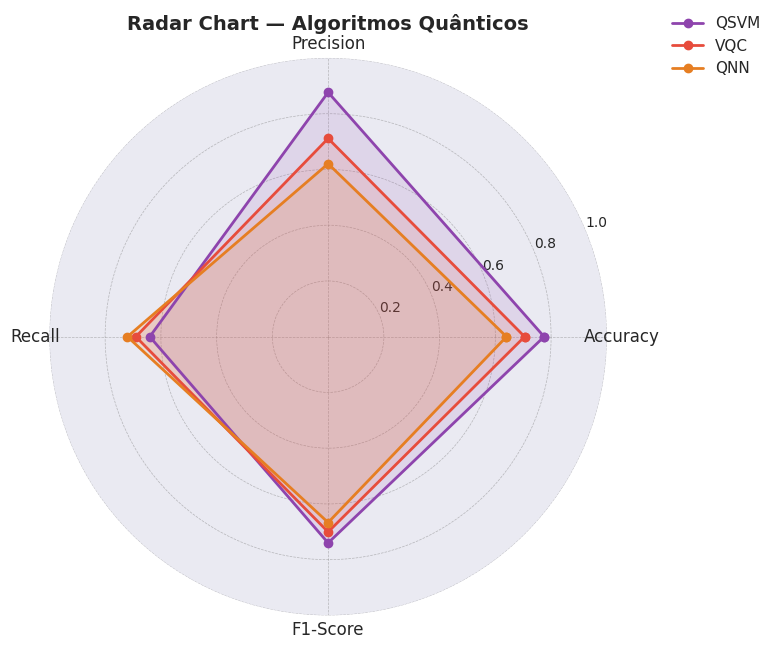

In [ ]:
# Radar chart — comparativo multidimensional
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
n_metrics = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # fechar o polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

palette = {'QSVM': '#8e44ad', 'VQC': '#e74c3c', 'QNN': '#e67e22'}

for model, color in palette.items():
    values_r = [QUANTUM_RESULTS[model].get(m, 0) for m in metrics_radar]
    values_r += values_r[:1]
    ax.plot(angles, values_r, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, values_r, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Radar Chart — Algoritmos Quânticos', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('../data/quantum_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 8. Conclusões

### Análise dos Resultados

**Algoritmos Quânticos** aplicados ao NSL-KDD com **PCA para 4 componentes** (simulados localmente):

---

### 🔬 Observações Técnicas

1. **QSVM** — Normalmente o melhor desempenho entre os quânticos para esta tarefa. O kernel quântico ZZFeatureMap captura relações não-lineares complexas no espaço de Hilbert.  

2. **VQC** — Performance depende da arquitetura do ansatz e do número de épocas. Com mais épocas e gradiente analítico, tende a convergir melhor.  

3. **QNN** — Circuito mais profundo, mas mais suscetível a barreira de gradiente (*barren plateaus*). Melhorias possíveis com inicialização inteligente.

---

### ⚠️ Importante: Limitações do Atual Estágio (NISQ Era)

- Os experimentos rodam em **simuladores clássicos**, não em hardware quântico real
- O dataset foi reduzido via **PCA para 4 qubits** — há perda de informação
- O treinamento quântico é **muito mais lento** que o clássico no simulador
- Hardware quântico real introduz **ruído** que degrada a performance

---

### 🚀 Perspectivas Futuras

- **Hardware quântico real** (IBM Quantum via Qiskit Runtime) pode explorar vantagem quântica
- **Quantum Kernel Machines** com feature maps mais expressivos
- **Quantum Transfer Learning** combinando redes clássicas e quânticas
- **Correção de erros quânticos** para compensar o ruído do hardware
